### This model used to predict insurance costs i used linear regression  then used polnomial regression the result is The train R-square value is:  0.842639
The test R-square value is:  0.849038 compared to The train R-square value is:  0.842639   and Root Mean Square Error =  0.352 so I think polonomial is better

## Import libraries

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv('insurance.csv')


In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Data Exploration

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df=df.drop_duplicates()

In [7]:
df.shape

(1337, 7)

In [8]:
df['age'].unique()

array([19, 18, 28, 33, 32, 31, 46, 37, 60, 25, 62, 23, 56, 27, 52, 30, 34,
       59, 63, 55, 22, 26, 35, 24, 41, 38, 36, 21, 48, 40, 58, 53, 43, 64,
       20, 61, 44, 57, 29, 45, 54, 49, 47, 51, 42, 50, 39], dtype=int64)

<Axes: xlabel='age', ylabel='Count'>

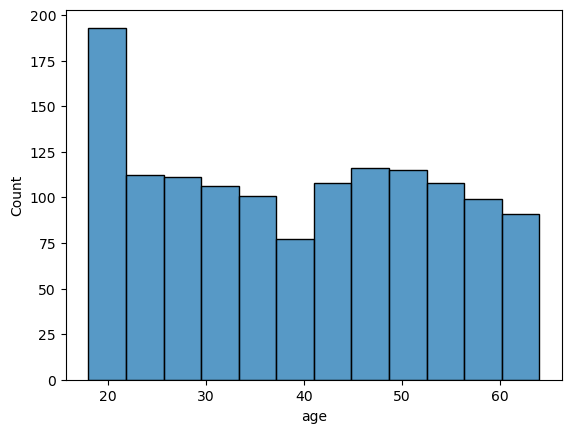

In [28]:
sns.histplot(df['age'])


In [10]:
df['sex'].unique()

array(['female', 'male'], dtype=object)

<Axes: xlabel='sex', ylabel='Count'>

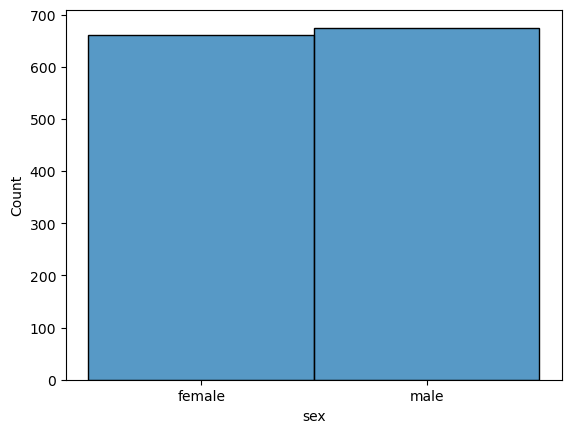

In [11]:
sns.histplot(df['sex'])

In [12]:
df['bmi'].unique()

array([27.9  , 33.77 , 33.   , 22.705, 28.88 , 25.74 , 33.44 , 27.74 ,
       29.83 , 25.84 , 26.22 , 26.29 , 34.4  , 39.82 , 42.13 , 24.6  ,
       30.78 , 23.845, 40.3  , 35.3  , 36.005, 32.4  , 34.1  , 31.92 ,
       28.025, 27.72 , 23.085, 32.775, 17.385, 36.3  , 35.6  , 26.315,
       28.6  , 28.31 , 36.4  , 20.425, 32.965, 20.8  , 36.67 , 39.9  ,
       26.6  , 36.63 , 21.78 , 30.8  , 37.05 , 37.3  , 38.665, 34.77 ,
       24.53 , 35.2  , 35.625, 33.63 , 28.   , 34.43 , 28.69 , 36.955,
       31.825, 31.68 , 22.88 , 37.335, 27.36 , 33.66 , 24.7  , 25.935,
       22.42 , 28.9  , 39.1  , 36.19 , 23.98 , 24.75 , 28.5  , 28.1  ,
       32.01 , 27.4  , 34.01 , 29.59 , 35.53 , 39.805, 26.885, 38.285,
       37.62 , 41.23 , 34.8  , 22.895, 31.16 , 27.2  , 26.98 , 39.49 ,
       24.795, 31.3  , 38.28 , 19.95 , 19.3  , 31.6  , 25.46 , 30.115,
       29.92 , 27.5  , 28.4  , 30.875, 27.94 , 35.09 , 29.7  , 35.72 ,
       32.205, 28.595, 49.06 , 27.17 , 23.37 , 37.1  , 23.75 , 28.975,
      

<Axes: xlabel='bmi', ylabel='Count'>

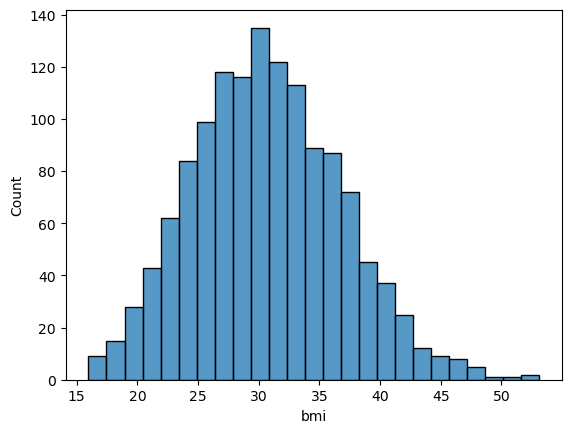

In [13]:
sns.histplot(df['bmi'])

In [14]:
df['children'].unique()

array([0, 1, 3, 2, 5, 4], dtype=int64)

<Axes: xlabel='children', ylabel='Count'>

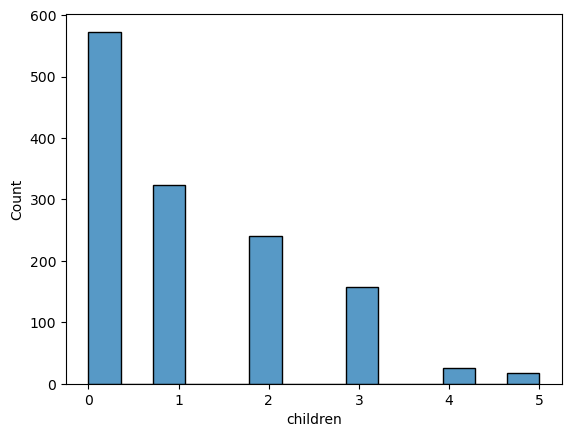

In [15]:
sns.histplot(df['children'])

In [16]:
df['smoker'].value_counts()

no     1063
yes     274
Name: smoker, dtype: int64

<Axes: xlabel='smoker', ylabel='Count'>

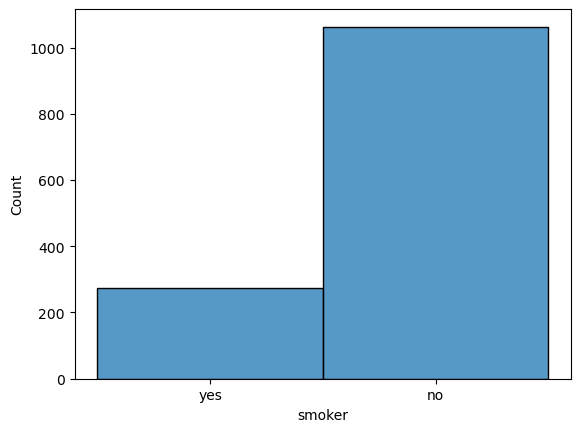

In [17]:
sns.histplot(df['smoker'])

In [17]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

<Axes: xlabel='region', ylabel='Count'>

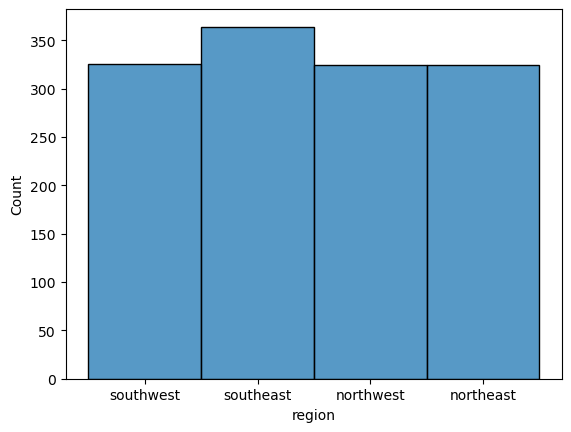

In [18]:
sns.histplot(df['region'])

<Axes: xlabel='charges', ylabel='Count'>

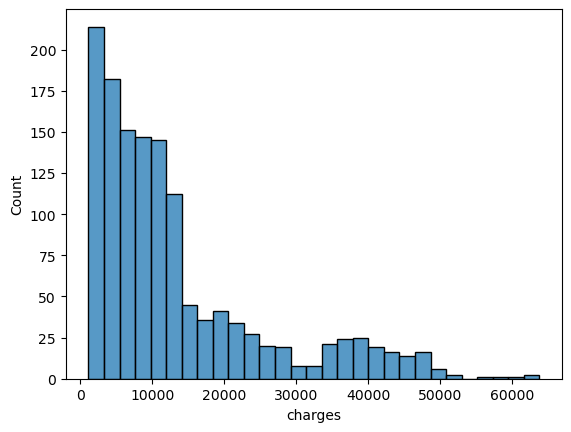

In [19]:
sns.histplot(df['charges'])

In [20]:
df['charges'].skew()

1.5153909108403483

In [23]:
corr=df.corr()

C:\Users\Omar\AppData\Local\Temp\ipykernel_8488\1726683880.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr=df.corr()


In [24]:
corr

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


In [26]:
corr['charges']

age         0.298308
bmi         0.198401
children    0.067389
charges     1.000000
Name: charges, dtype: float64

In [ ]:
sns.pairplot()

##### there is skewness in column charge

# handle data

In [21]:
Target=np.log(df['charges'])

<Axes: xlabel='charges', ylabel='Count'>

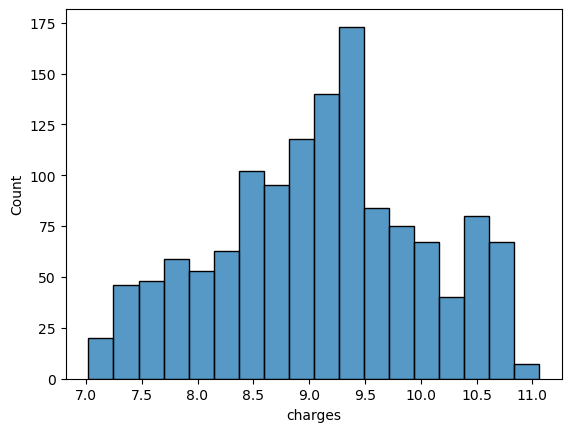

In [22]:
sns.histplot(Target)

###### we can divide the bmi for 5 categories  (Underweight: bmi less than 18.5,Normal weight: bmi 18.5 to 24.9,Overweight: bmi 25 to 29.9,Obese: bmi 30 or higher)

In [23]:
def Bmi_categories(x):
    if x < 18.5:
        return 'Underweight'
    elif 18.5<=x<25  :
        return 'Normal weight'
    elif 25<=x<30  :
        return 'Overweight'
    elif 30<=x  :
        return 'Obese'
df['bmi']=df['bmi'].apply(Bmi_categories)    

In [24]:
df['bmi'].value_counts()

Obese            706
Overweight       386
Normal weight    225
Underweight       20
Name: bmi, dtype: int64

In [25]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### split data

In [26]:
from sklearn.model_selection import train_test_split
x,y=df.drop('charges',axis=1),Target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=1)


In [27]:
print('The shape of x_train',x_train.shape)
print('The shape of y_train',y_train.shape)

print('The shape of x_test',x_test.shape)
print('The shape of y_test',y_test.shape)


The shape of x_train (935, 6)
The shape of y_train (935,)
The shape of x_test (402, 6)
The shape of y_test (402,)


In [28]:
x_train.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64

####  categrical data

In [29]:
categorical_df=df.select_dtypes('object').columns

In [30]:
categorical_df

Index(['sex', 'bmi', 'smoker', 'region'], dtype='object')

In [31]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(sparse=False,drop='first')
x_train_ohe=pd.DataFrame(ohe.fit_transform(x_train[categorical_df]),columns=ohe.get_feature_names_out(input_features=categorical_df))
x_test_ohe=pd.DataFrame(ohe.transform(x_test[categorical_df]),columns=ohe.get_feature_names_out(input_features=categorical_df))
x_train.reset_index(inplace=True,drop=True)
x_test.reset_index(inplace=True,drop=True)

C:\anconda3 2020\envs\myenv\lib\site-packages\sklearn\preprocessing\_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [32]:
x_train=pd.concat([x_train,x_train_ohe],axis=1)
x_test=pd.concat([x_test,x_test_ohe],axis=1)

In [33]:
x_train.head()

,age,sex,bmi,children,smoker,region,sex_male,bmi_Obese,bmi_Overweight,bmi_Underweight,smoker_yes,region_northwest,region_southeast,region_southwest
0,50,female,Overweight,0,no,northeast,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,58,female,Overweight,0,no,northwest,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,61,male,Obese,3,no,southwest,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,27,female,Obese,0,yes,southwest,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,38,female,Overweight,1,no,northeast,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [34]:
x_test.head()

,age,sex,bmi,children,smoker,region,sex_male,bmi_Obese,bmi_Overweight,bmi_Underweight,smoker_yes,region_northwest,region_southeast,region_southwest
0,44,female,Obese,0,yes,northwest,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,57,male,Obese,0,no,northwest,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,55,female,Obese,1,no,northeast,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,39,female,Obese,0,no,southeast,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,41,male,Obese,0,no,southeast,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [35]:
x_train.isnull().sum()

age                 0
sex                 0
bmi                 0
children            0
smoker              0
region              0
sex_male            0
bmi_Obese           0
bmi_Overweight      0
bmi_Underweight     0
smoker_yes          0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64

In [36]:
x_train.drop(categorical_df,inplace=True,axis=1)
x_test.drop(categorical_df,inplace=True,axis=1)

In [37]:
x_train.head()

,age,children,sex_male,bmi_Obese,bmi_Overweight,bmi_Underweight,smoker_yes,region_northwest,region_southeast,region_southwest
0,50,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,58,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,61,3,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,27,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
4,38,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [38]:
x_test.head()

,age,children,sex_male,bmi_Obese,bmi_Overweight,bmi_Underweight,smoker_yes,region_northwest,region_southeast,region_southwest
0,44,0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,57,0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,55,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,39,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,41,0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## Modeling

### Linear Regression

In [131]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
lr=LinearRegression()
lr_fit=lr.fit(x_train,y_train)
print(lr_fit.score(x_train,y_train))

0.7623326962428771


In [78]:
y_train_pred=lr_fit.predict(x_train)
y_pred=lr_fit.predict(x_test)
print(lr_fit.score(x_test,y_test))

0.7781988542501204


In [79]:
MSE=mean_squared_error(y_test,y_pred)

In [139]:
print ('Mean Square Error = ',MSE.round(3))
print ('Root Mean Square Error = ',np.sqrt(MSE).round(3))

Mean Square Error =  0.124
Root Mean Square Error =  0.352


### Polynomial Regression

In [117]:
from sklearn.preprocessing import PolynomialFeatures
Pf=PolynomialFeatures(degree=2)
pf_xtrain=Pf.fit_transform(x_train)
pf_xtest=Pf.transform(x_test)

In [118]:
lr2_fit=LinearRegression().fit(pf_xtrain,y_train)

In [119]:
print(lr2_fit.score(pf_xtrain,y_train))

0.842638624061248


In [127]:
y2_train_pred=lr2_fit.predict(pf_xtrain)
y2_pred=lr2_fit.predict(pf_xtest)

In [128]:
print(lr2_fit.score(pf_xtest,y_test))

0.8490381693314858


In [141]:
r2_train=r2_score(y_train,y2_train_pred)
r2_test=r2_score(y_test,y2_pred)
print('The train R-square value is: ', r2_train.round(6))
print('The test R-square value is: ', r2_test.round(6))

The train R-square value is:  0.842639
The test R-square value is:  0.849038


In [142]:
MSE=mean_squared_error(y_test,y2_pred)
print ('Mean Square Error = ',MSE.round(3))
print ('Root Mean Square Error = ',np.sqrt(MSE).round(3))

Mean Square Error =  0.124
Root Mean Square Error =  0.352
